**Rawan Alharthi 444001029**

**Mashael Abdali 444001062**

**Shaimaa Alghamdi 444000746**



# Importing the necessary libraries

In [ ]:
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import boxcox
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import  RandomForestClassifier, GradientBoostingClassifier,ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
warnings.filterwarnings('ignore')

/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
# Load the dataset

from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/cardio_train.csv', delimiter=';')

# Display basic information
print(data.info())
print(data.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke

In [ ]:
data['age']=data['age'].apply(lambda x: x/365).astype(int)

data['height']=data['height'].apply(lambda x: x/100)
data.drop("id", axis = 1 , inplace = True )

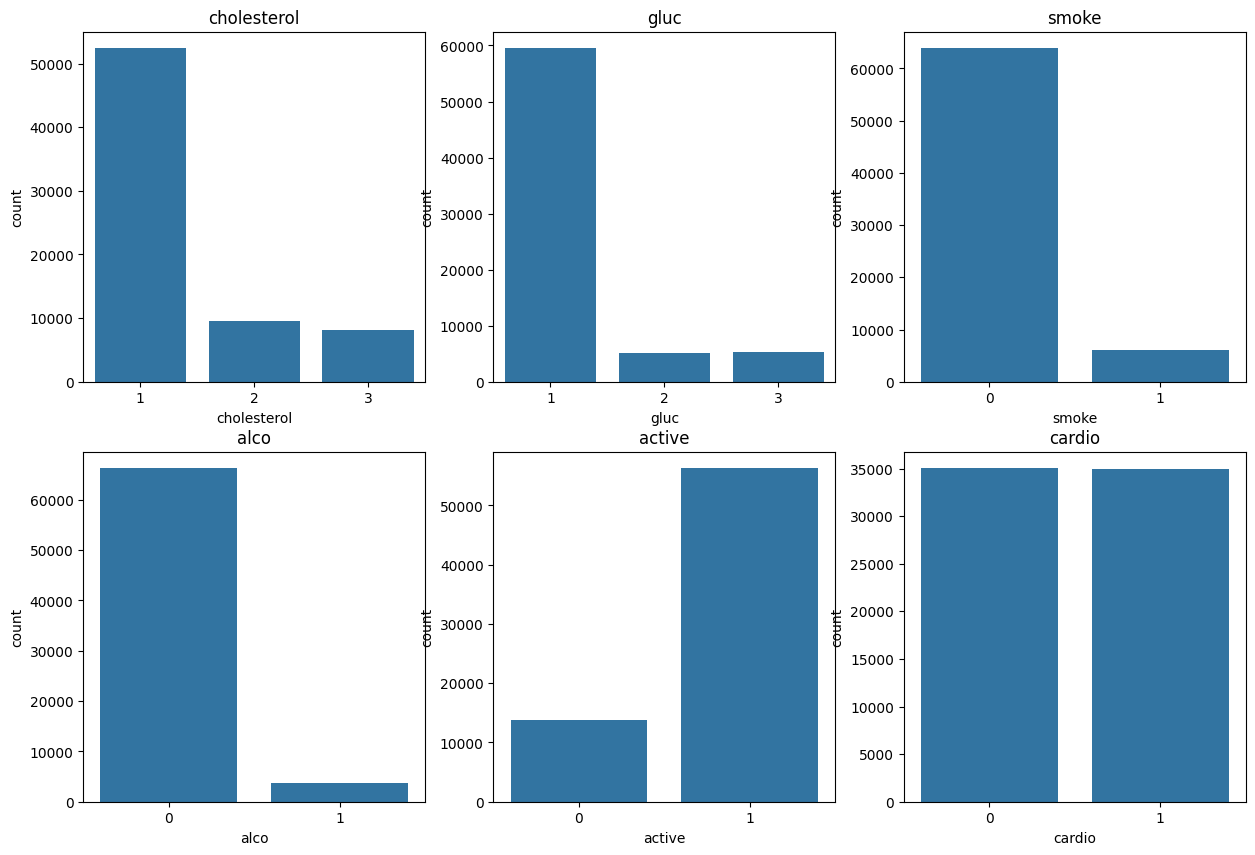

In [ ]:
plt.figure(figsize=(15, 10))  # Increase figure size for more space

for i, column in enumerate(data[['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']].columns):
    plt.subplot(2, 3, i + 1)  # Adjust the subplot grid size accordingly
    sns.countplot(x=data[column])
    plt.title(f'{column}')

In [ ]:
columns_to_up_sample = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']  # These are the columns with imbalanced categories

# Create a copy of the original dataframe to preserve it
df_copy = data.copy()


# Initialize SMOTE
# Loop through each column in the columns_to_up_sample list
for column in columns_to_up_sample:
    print(f" UP SAMPLING : {column}")
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    # Extract the column to treat as the target variable (y)
    X = df_copy.drop(columns=column)  # All other columns except the current one
    y = df_copy[column]

    X_res, y_res = smote.fit_resample(X, y)
    X_res[column] = y_res

    df_copy =  X_res.copy()

 UP SAMPLING : cholesterol
 UP SAMPLING : gluc
 UP SAMPLING : smoke
 UP SAMPLING : alco
 UP SAMPLING : active


In [ ]:
print("New Dataset Shape : " , df_copy.shape )
df = df_copy

New Dataset Shape :  (1872656, 12)


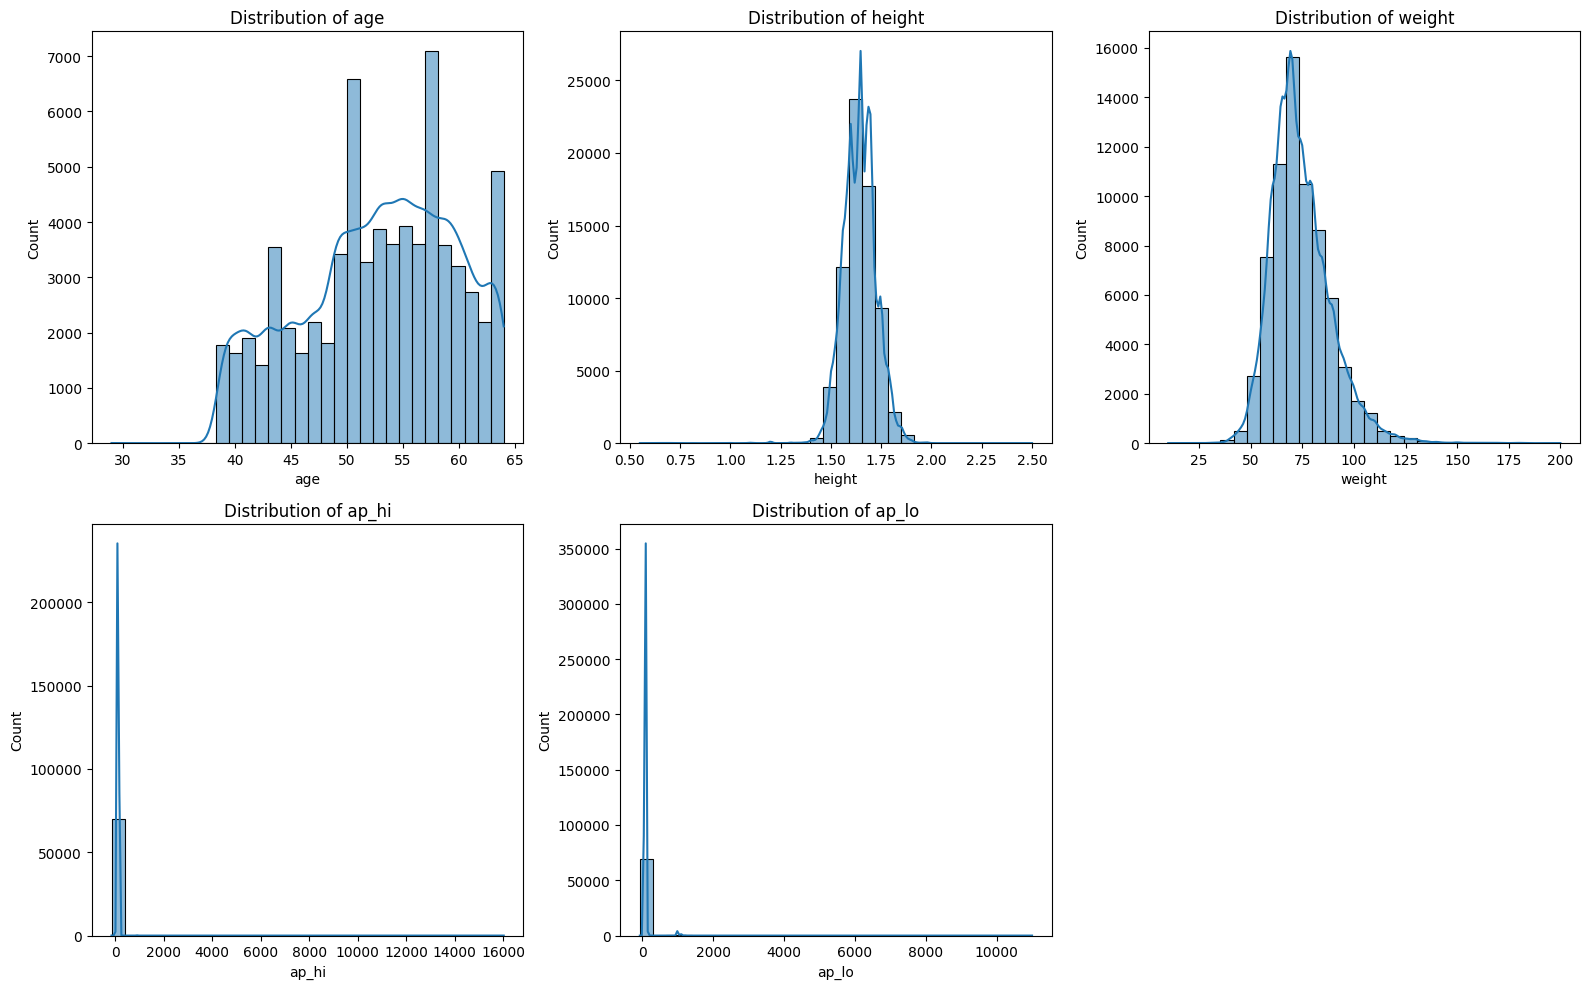

In [ ]:
plt.figure(figsize=(16, 10))
for i, column in enumerate(['age', 'height', 'weight', 'ap_hi', 'ap_lo'], start=1):
    plt.subplot(2, 3, i)
    sns.histplot(data[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

In [ ]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

df['map'] = df['ap_lo'] + (df['ap_hi'] - df['ap_lo'])/3

df['bmi']=df['weight']/(df['height'])**2

df['sys_dsys_ratio'] = df['ap_hi'] / df['ap_lo']
df['cholesterol']=df['cholesterol'].apply(lambda x: 'normal' if x==1 else('above_normal' if x==2 else 'well_above_normal'))
df['gluc']=df['gluc'].apply(lambda x: 'normal' if x==1 else('above_normal' if x==2 else 'well_above_normal'))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1872656 entries, 0 to 1872655
Data columns (total 16 columns):
 #   Column          Dtype  
---  ------          -----  
 0   age             int64  
 1   gender          int64  
 2   height          float64
 3   weight          float64
 4   ap_hi           int64  
 5   ap_lo           int64  
 6   cardio          int64  
 7   cholesterol     object 
 8   gluc            object 
 9   smoke           int64  
 10  alco            int64  
 11  active          int64  
 12  pulse_pressure  int64  
 13  map             float64
 14  bmi             float64
 15  sys_dsys_ratio  float64
dtypes: float64(5), int64(9), object(2)
memory usage: 228.6+ MB


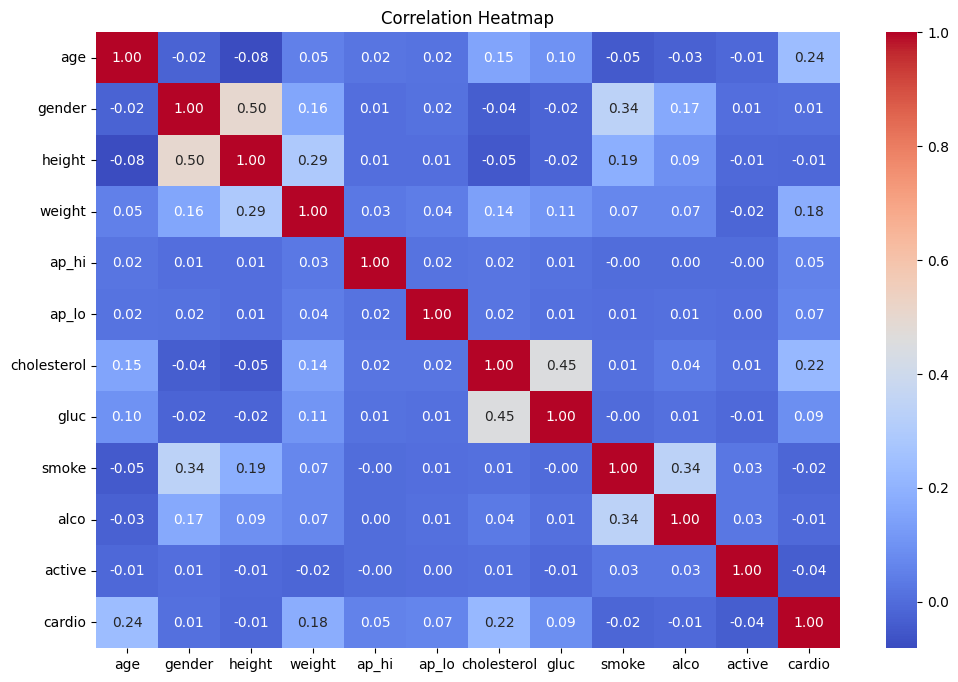

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
num_cols=df.select_dtypes(exclude='object').columns
cat_cols=df.select_dtypes(include='object').columns

age=np.array(df['age'])
_, opt_lambda=boxcox(age)
print(opt_lambda)

1.2442624963943845


# Selecting Features and Target

In [ ]:
df['age_box']=boxcox(df['age'], lmbda=opt_lambda)
features=df[['age_box','weight', 'cholesterol', 'gluc', 'smoke', 'alco','pulse_pressure', 'map', 'bmi']]
target=df['cardio']
num_features=features.select_dtypes(exclude='object').columns
cat_features=features.select_dtypes(include='object').columns
num_features

Index(['age_box', 'weight', 'smoke', 'alco', 'pulse_pressure', 'map', 'bmi'], dtype='object')

In [ ]:
print(cat_features)
print("Feature:", features)
print("Target \n",target)

Index(['cholesterol', 'gluc'], dtype='object')
Feature:             age_box     weight        cholesterol          gluc  smoke  alco  \
0        103.680998  62.000000             normal        normal      0     0   
1        116.836581  85.000000  well_above_normal        normal      0     0   
2        106.287445  64.000000  well_above_normal        normal      0     0   
3         98.506408  82.000000             normal        normal      0     0   
4         95.938664  56.000000             normal        normal      0     0   
...             ...        ...                ...           ...    ...   ...   
1872651  135.746953  95.205398             normal  above_normal      0     0   
1872652  122.182748  78.403099       above_normal  above_normal      0     0   
1872653  106.287445  84.172106             normal        normal      1     1   
1872654  116.836581  90.050453             normal        normal      1     1   
1872655  122.182748  92.095742       above_normal        normal 

# Scaling Numerical Features

In [ ]:
scaler=StandardScaler()
features[num_features]=scaler.fit_transform(features[num_features])
features

,age_box,weight,cholesterol,gluc,smoke,alco,pulse_pressure,map,bmi
0,-0.281061,-1.135112,normal,normal,-1.508463,-1.004903,-0.023810,-0.181988,-1.182106
1,0.485372,0.273894,well_above_normal,normal,-1.508463,-1.004903,0.092703,-0.024509,1.257840
2,-0.129212,-1.012590,well_above_normal,normal,-1.508463,-1.004903,0.150959,-0.181988,-0.892057
3,-0.582528,0.090110,normal,normal,-1.508463,-1.004903,0.092703,0.069978,0.087394
4,-0.732123,-1.502678,normal,normal,-1.508463,-1.004903,0.034447,-0.339467,-0.985552
...,...,...,...,...,...,...,...,...,...
1872651,1.587074,0.899088,normal,above_normal,-1.508463,-1.004903,0.145133,0.192812,1.464082
1872652,0.796835,-0.130240,above_normal,above_normal,-1.508463,-1.004903,-5.208604,5.707725,0.157842
1872653,-0.129212,0.223176,normal,normal,0.662926,0.995120,0.150959,0.006987,0.034374
1872654,0.485372,0.583290,normal,normal,0.662926,0.995120,0.121831,-0.103248,0.392669


# Encoding Categorical Features

In [ ]:
features=pd.get_dummies(features, columns=['cholesterol', 'gluc'])
features

,age_box,weight,smoke,alco,pulse_pressure,map,bmi,cholesterol_above_normal,cholesterol_normal,cholesterol_well_above_normal,gluc_above_normal,gluc_normal,gluc_well_above_normal
0,-0.281061,-1.135112,-1.508463,-1.004903,-0.023810,-0.181988,-1.182106,False,True,False,False,True,False
1,0.485372,0.273894,-1.508463,-1.004903,0.092703,-0.024509,1.257840,False,False,True,False,True,False
2,-0.129212,-1.012590,-1.508463,-1.004903,0.150959,-0.181988,-0.892057,False,False,True,False,True,False
3,-0.582528,0.090110,-1.508463,-1.004903,0.092703,0.069978,0.087394,False,True,False,False,True,False
4,-0.732123,-1.502678,-1.508463,-1.004903,0.034447,-0.339467,-0.985552,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1872651,1.587074,0.899088,-1.508463,-1.004903,0.145133,0.192812,1.464082,False,True,False,True,False,False
1872652,0.796835,-0.130240,-1.508463,-1.004903,-5.208604,5.707725,0.157842,True,False,False,True,False,False
1872653,-0.129212,0.223176,0.662926,0.995120,0.150959,0.006987,0.034374,False,True,False,False,True,False
1872654,0.485372,0.583290,0.662926,0.995120,0.121831,-0.103248,0.392669,False,True,False,False,True,False


# Splitting Data and  Model Training and Evaluation

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(features, target, random_state=42,test_size=.2)
estimators = [
    ('RandomForestClassifier', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('ExtraTreesClassifier', ExtraTreesClassifier(
                n_estimators=50,
                max_depth=None,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features='sqrt',  # Correct assignment
                random_state=42
            )),
   ('GradientBoostingClassifier' ,GradientBoostingClassifier(n_estimators=50, learning_rate=1.0,
    max_depth=1, random_state=0) ),

]

In [ ]:
for model in estimators:
    print( f" {model[0]}  Accuracy : " , end = "")
    model[1].fit(x_train , y_train)
    print( model[1].score( x_test , y_test))

 RandomForestClassifier  Accuracy : 0.9692709835207672
 ExtraTreesClassifier  Accuracy : 0.9569916589236701
 GradientBoostingClassifier  Accuracy : 0.7858927942071705


# Deep Learning Model

# Ensure all features are numeric and properly scaled
## Split training data for validation
## Build the neural network model
## Compile the model

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)


nn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Output probability for binary classification
])


nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,801 (175.00 KB)

 Trainable params: 44,801 (175.00 KB)

 Non-trainable params: 0 (0.00 B)

# Train the model

In [ ]:
history = nn_model.fit(X_train_split, y_train_split, epochs=10, batch_size=32, validation_data=(X_val_split, y_val_split))

Epoch 1/10
37454/37454 ━━━━━━━━━━━━━━━━━━━━ 81s 2ms/step - accuracy: 0.7995 - loss: 0.4127 - val_accuracy: 0.8416 - val_loss: 0.3392
Epoch 2/10
37454/37454 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - accuracy: 0.8353 - loss: 0.3502 - val_accuracy: 0.8523 - val_loss: 0.3150
Epoch 3/10
37454/37454 ━━━━━━━━━━━━━━━━━━━━ 91s 2ms/step - accuracy: 0.8426 - loss: 0.3361 - val_accuracy: 0.8560 - val_loss: 0.3051
Epoch 4/10
37454/37454 ━━━━━━━━━━━━━━━━━━━━ 132s 2ms/step - accuracy: 0.8466 - loss: 0.3272 - val_accuracy: 0.8595 - val_loss: 0.2973
Epoch 5/10
37454/37454 ━━━━━━━━━━━━━━━━━━━━ 82s 2ms/step - accuracy: 0.8496 - loss: 0.3214 - val_accuracy: 0.8621 - val_loss: 0.2938
Epoch 6/10
37454/37454 ━━━━━━━━━━━━━━━━━━━━ 91s 2ms/step - accuracy: 0.8518 - loss: 0.3163 - val_accuracy: 0.8644 - val_loss: 0.2877
Epoch 7/10
37454/37454 ━━━━━━━━━━━━━━━━━━━━ 134s 2ms/step - accuracy: 0.8518 - loss: 0.3151 - val_accuracy: 0.8659 - val_loss: 0.2849
Epoch 8/10
37454/37454 ━━━━━━━━━━━━━━━━━━━━ 80s 2ms/step - accuracy

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = nn_model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

11705/11705 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - accuracy: 0.8686 - loss: 0.2793
Test Accuracy: 0.8679


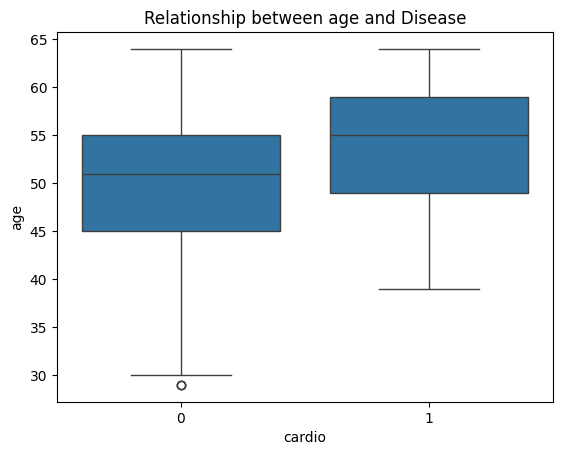

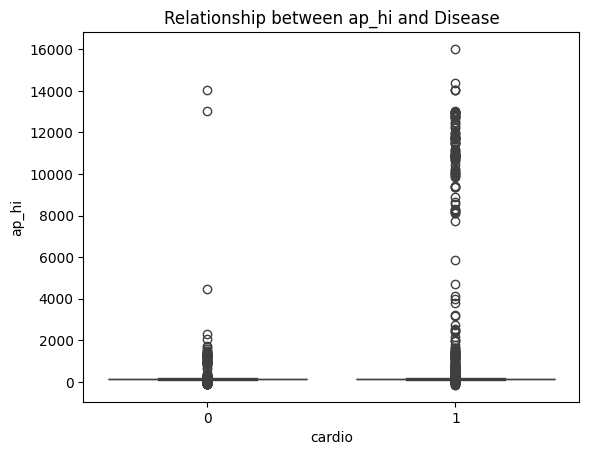

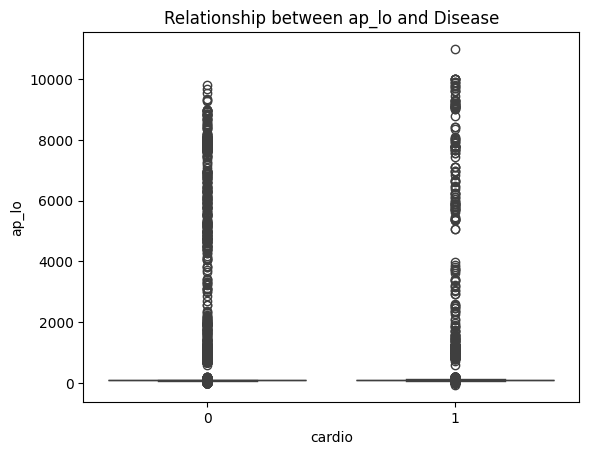

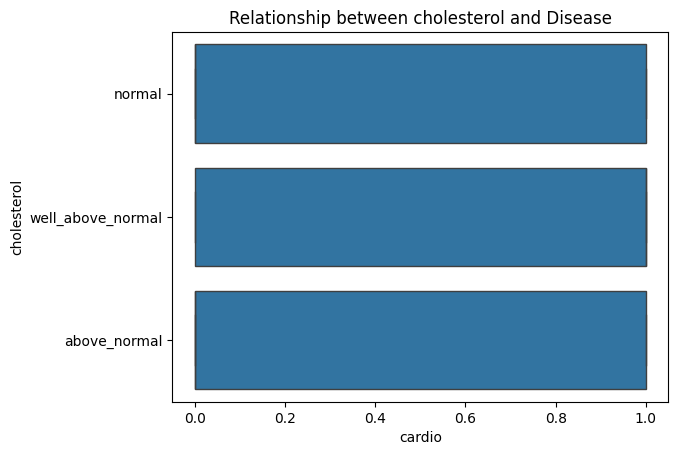

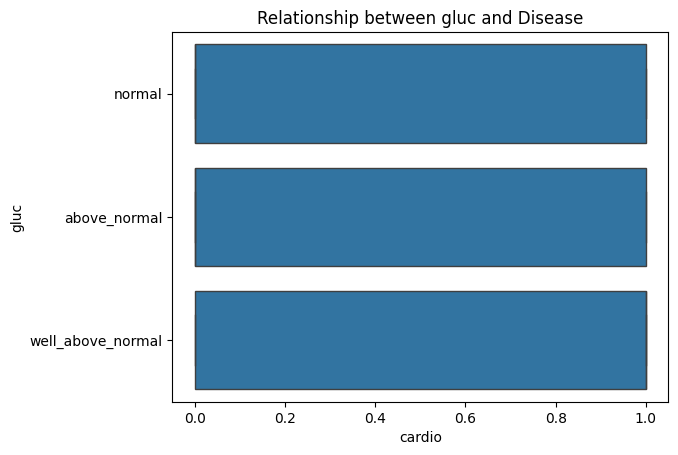

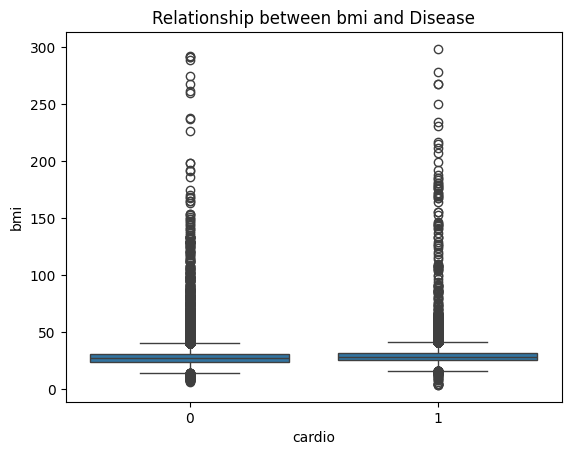

In [ ]:
# Visualizing Relationships Between Key Variables and Patient Condition
important_features = ['age', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'bmi']
for feature in important_features:
    sns.boxplot(x=df['cardio'], y=df[feature])
    plt.title(f'Relationship between {feature} and Disease')
    plt.show()

# Entering new patient data for prediction

In [ ]:
# Predict function with input alignment
def predict_example(example):
    # Convert the example to a DataFrame
    example_df = pd.DataFrame([example], columns=['age_box', 'weight', 'smoke', 'alco', 'pulse_pressure', 'map', 'bmi'])

    # Add missing columns and align with training data
    for col in features.columns:
        if col not in example_df.columns:
            example_df[col] = 0  # Add missing column with value 0

    # Ensure the same column order as in training
    example_df = example_df[features.columns]

    # Scale the input data
    example_scaled = scaler.transform(example_df)

    # Predict using the trained model
    prediction = nn_model.predict(example_scaled)
    return "Cardio Risk" if prediction[0] > 0.5 else "No Cardio Risk"

# Example input
example_input = [55, 70, 1, 0, 40, 95, 25]  # Replace with actual values
prediction_result = predict_example(example_input)
print(f"Prediction Result: {prediction_result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
Prediction Result: Cardio Risk


11705/11705 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step


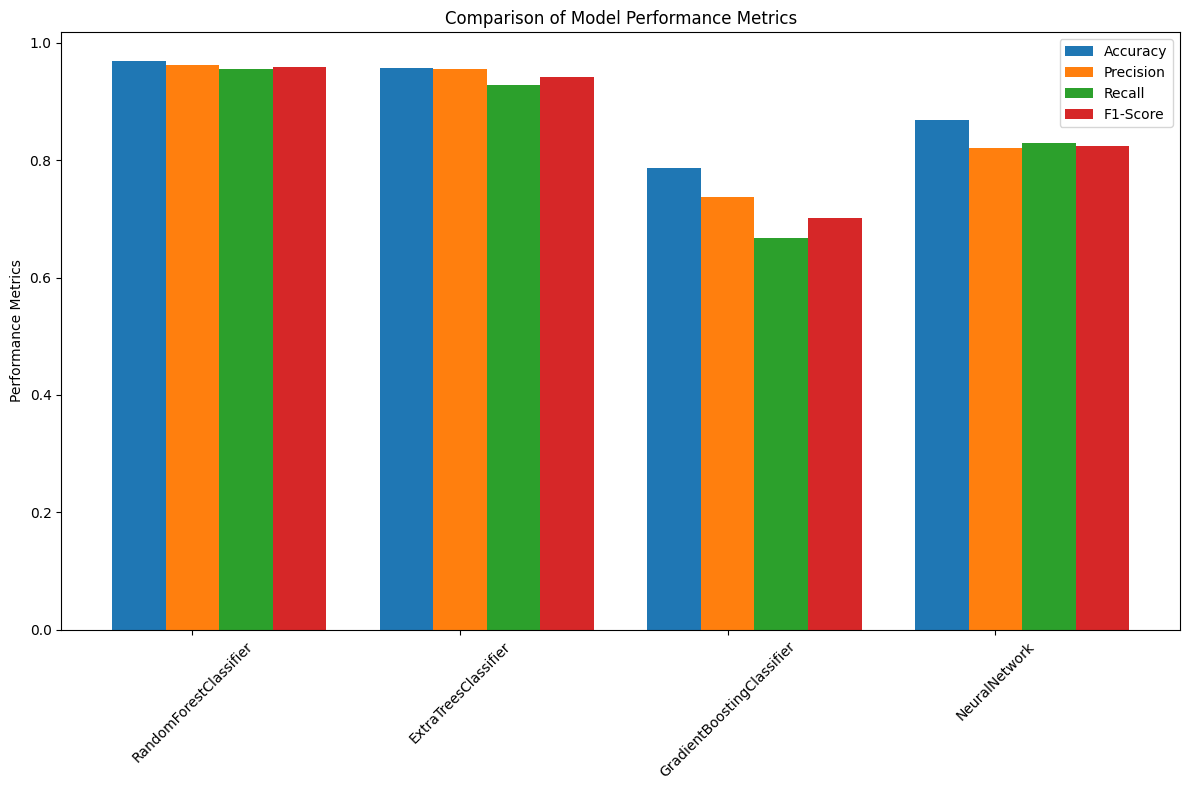

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# List of classifiers and their metrics
model_names = []
accuracies = []
precisions = []
recalls = []
f1_scores = []

# Calculate metrics for each model
for model_name, model in estimators:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    model_names.append(model_name)
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, average='binary'))
    recalls.append(recall_score(y_test, y_pred, average='binary'))
    f1_scores.append(f1_score(y_test, y_pred, average='binary'))

# Add Neural Network metrics
nn_y_pred = (nn_model.predict(X_test_scaled) > 0.5).astype(int)
model_names.append('NeuralNetwork')
accuracies.append(accuracy_score(y_test, nn_y_pred))
precisions.append(precision_score(y_test, nn_y_pred))
recalls.append(recall_score(y_test, nn_y_pred))
f1_scores.append(f1_score(y_test, nn_y_pred))

# Create a bar chart for comparison
x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(12, 8))
plt.bar(x - width, accuracies, width, label='Accuracy')
plt.bar(x, precisions, width, label='Precision')
plt.bar(x + width, recalls, width, label='Recall')
plt.bar(x + 2*width, f1_scores, width, label='F1-Score')

# Add labels and legend
plt.xticks(x, model_names, rotation=45)
plt.ylabel('Performance Metrics')
plt.title('Comparison of Model Performance Metrics')
plt.legend()
plt.tight_layout()

# Save the chart
#plt.savefig('/content/model_performance_comparison.png')
plt.show()
